In [ ]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [1]:
data = fetch_california_housing()
X,y = data.data, data.target
print(X.shape)
print(y.shape)
print(data.feature_names)

(20640, 8)
(20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [2]:
#looking at coorelations with target
correlations = np.array([np.corrcoef(
    X[:,j], y)[0,1] for j in range(X.shape[1])])

for name, corr in zip(data.feature_names, correlations):
    print(f"{name:12s} r = {corr:.3f}")
    

MedInc       r = 0.688
HouseAge     r = 0.106
AveRooms     r = 0.152
AveBedrms    r = -0.047
Population   r = -0.025
AveOccup     r = -0.024
Latitude     r = -0.144
Longitude    r = -0.046


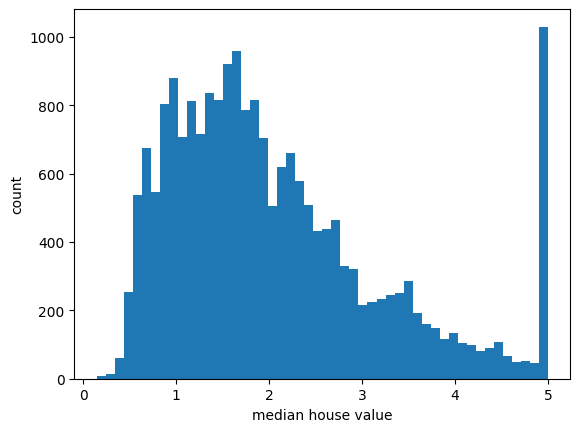

In [3]:
#observing the target distribution
plt.hist(y, bins = 50)
plt.xlabel('median house value')
plt.ylabel('count')
plt.show()


The target values are skewed to the left. and at x = 5, there is a spike: the cap for this data was 500,000, and all above this threshold were counted at the threshold, which corrupts both mean and variance, as we had assumed $\epsilon$ ~ $\mathcal{N}(0, \sigma^{2})$, the noise is no longer constant across the price range, it's larger at the top end where capping occured.

**Heteroscedasticity** => the noise variance $\sigma^{2}$ is not constant. It depends on the price level. But our Gaussaian likelihood assumed a single fixed $\sigma{^2}$ for every data point.

So, we filter the capped houses out, so that our Gaussian assumption remains honest.

In [4]:
mask = y < 5.0
X_clean, y_clean = X[mask], y[mask]
print(f"removed {X.shape[0]- X_clean.shape[0]} capped samples")
print(f"remaining: {X_clean.shape[0]} samples")

removed 992 capped samples
remaining: 19648 samples


The features: MedInc, HouseAge, AveRooms have positive correlation while the other features have negative correlation with the target value. MedInc has the highest correlation with the target. 

**Standarization**
Standarization is neccessary for smooth preprocessing, and it is mathematically
neccessary as well. Standarization makes units disappear, and helps 
for $b_j^{2}$ to correspond with equal importance given the feature. 
This helps in setting our prior stronger. 


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size = 0.2, random_state = 42)


In [6]:
#standardising using training mean and std only
X_mean = X_train.mean(axis = 0)
X_std = X_train.std(axis = 0)

X_train_s = (X_train -X_mean) / X_std
X_test_s = (X_test- X_mean)/ X_std

print( "feature means" , X_train_s.mean(axis = 0).round(3))
print("feature stds " , X_train_s.std(axis = 0).round(3)) 


feature means [ 0.  0. -0. -0.  0. -0. -0.  0.]
feature stds  [1. 1. 1. 1. 1. 1. 1. 1.]


**Generating the design matrix $\Phi$**

In [7]:
#Building the design matrix
def make_design_matrix(X):
    N = X.shape[0] #no of data points
    ones = np.ones((N,1))#to add a bias column 
    return np.hstack([ones, X])

Phi_train = make_design_matrix(X_train_s)
Phi_test  = make_design_matrix(X_test_s)

print("Design matrix shape: ", Phi_train.shape)

    

Design matrix shape:  (15718, 9)


In [8]:
#computing correlations on standardised training data
correlations = np.array([np.corrcoef(X_train_s[ :, j], y_train)[0,1]
                         for j in range(X_train_s.shape[1])])

for name, corr in zip(data.feature_names, correlations):
    print(f"{name:12s} r = {corr:.3f}")
    

MedInc       r = 0.648
HouseAge     r = 0.064
AveRooms     r = 0.111
AveBedrms    r = -0.057
Population   r = 0.012
AveOccup     r = -0.020
Latitude     r = -0.150
Longitude    r = -0.045


**Building the matrix B**


In [9]:
correlations

array([ 0.64820092,  0.06444877,  0.11097338, -0.05690848,  0.01226982,
       -0.01971629, -0.1504274 , -0.04500405])

In [10]:
alpha = 2.0
b2_features = alpha * correlations**2
b2_all = np.concatenate([[1000.0], b2_features])
#large b0 for the intercept

B = np.diag(b2_all)
B_inv = np.diag(1/b2_all)

print("b^2 values: ")
print(f"  intercept : {b2_all[0]}")

for name, b2 in zip(data.feature_names, b2_all[1:]):
    print(f" {name:12s}:  {b2:.4f}")

b^2 values: 
  intercept : 1000.0
 MedInc      :  0.8403
 HouseAge    :  0.0083
 AveRooms    :  0.0246
 AveBedrms   :  0.0065
 Population  :  0.0003
 AveOccup    :  0.0008
 Latitude    :  0.0453
 Longitude   :  0.0041


$\sigma = 1.0$
Solving equation (19) given in the mathematical derivations
$$
\theta_{MAP} = (\Phi^{T}\Phi + \sigma^2B^{-1})^{-1}{\Phi}^{T}y
$$

We will solve it as 
$A\theta= b$


where 
$ A = \Phi^{T}\Phi + \sigma^2B^{-1}$,

$ b = \Phi^{T}y$

In [11]:
sigma2 = 1.0 #initial estimate

A = Phi_train.T @ Phi_train + sigma2 * B_inv
b = Phi_train.T @ y_train

theta_map = np.linalg.solve(A,b)


In [12]:
print(f"intercept: {theta_map[0]}")
for feature, theta in zip(data.feature_names, theta_map[1:]):
    print(f" {feature:12s} theta = { theta}")

intercept: 1.920532259159388
 MedInc       theta = 0.6857322223817908
 HouseAge     theta = 0.1093351710424434
 AveRooms     theta = -0.254249037608015
 AveBedrms    theta = 0.27236487041172913
 Population   theta = 0.00663429920141602
 AveOccup     theta = -0.035229543080141534
 Latitude     theta = -0.7147976532435503
 Longitude    theta = -0.6870368809561829


Our model can be written as
$y = \Phi*\theta_{MAP}$
given we have added dummy feature while building feature matrix


In [14]:
y_pred = Phi_test @ theta_map
mse = (1/X_test.shape[0])*np.sum((y_test - y_pred)**2)

In [15]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.6443


This is not a bad result given that we have used degree 1 features and 
first guess for B matrix and not cross-validated, and fixed variance $\sigma^{2} = 1.0$ without 
estimating it from data. 

In [16]:
residuals = y_test - y_pred

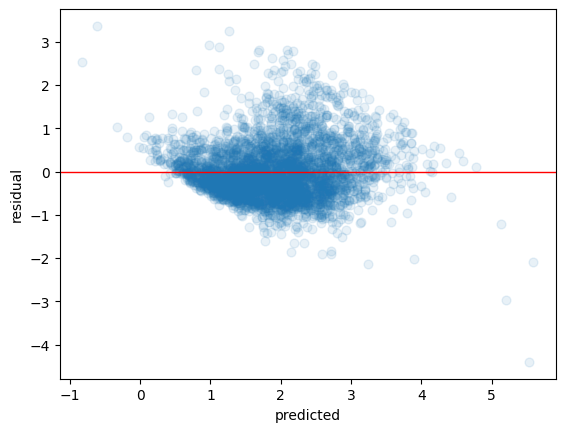

In [17]:
plt.scatter(y_pred, residuals, alpha = 0.1, s = 40)
plt.axhline(0, color = "red", linewidth = 1)
plt.xlabel("predicted")
plt.ylabel("residual")
plt.show()

We can see that almost all of the data points residual are clustered around zero. However,at almost around the 
endpoints the residuals are drifing far away. 
for low median prices, residual is positive(low prediction) and for high prices, residual is negative( high prediction)

We can introduce polynomial features to remedy this, but for now, we can 
improve our model by **cross-validation** to find the best $b_j^2$ which is defined as in (7) in mathematical derivations

In [18]:
#split training data into train and validation
X_tr, X_val, y_tr , y_val = train_test_split(
    X_train_s, y_train, test_size = 0.2, random_state = 42)

Phi_tr = make_design_matrix(X_tr)
Phi_val = make_design_matrix(X_val)
alphas = [0.1,0.2,0.3,0.4,0.5,1.0,2.0,3.0,3.2, 5.0, 10.0, 50.0]
val_rmses = []
for alpha in alphas:
    b2_features = alpha * correlations**2
    b2_all = np.concatenate([[1000.0],b2_features])
    B = np.diag(b2_all)
    B_inv = np.diag(1/b2_all)
    A = Phi_tr.T @ Phi_tr+ sigma2 * B_inv
    b = Phi_tr.T @ y_tr
    theta_map = np.linalg.solve(A,b)
    y_pre = Phi_val @ theta_map #model
    mse = 1/X_val.shape[0]*np.sum((y_val - y_pre)**2)
    rmse = np.sqrt(mse)
    val_rmses.append(rmse)


In [19]:
for alpha, rmse in zip(alphas, val_rmses):
    print(f"alpha = {alpha:5.1f} val RMSE = {rmse:.4f}")

best_alpha = alphas[np.argmin(val_rmses)]
print(f"\noptimal alpha: {best_alpha}")

alpha =   0.1 val RMSE = 0.6564
alpha =   0.2 val RMSE = 0.6414
alpha =   0.3 val RMSE = 0.6334
alpha =   0.4 val RMSE = 0.6287
alpha =   0.5 val RMSE = 0.6256
alpha =   1.0 val RMSE = 0.6194
alpha =   2.0 val RMSE = 0.6171
alpha =   3.0 val RMSE = 0.6166
alpha =   3.2 val RMSE = 0.6166
alpha =   5.0 val RMSE = 0.6164
alpha =  10.0 val RMSE = 0.6165
alpha =  50.0 val RMSE = 0.6166

optimal alpha: 5.0


the prior was too tight among the smaller alphas, as it went up to 5.0,
the prior looses up, but after that, the prior is loose enough that it barely
matters.


In [20]:
#testing against the original test set using whole training set
optimal_alpha = 5.0
b2_features = optimal_alpha * correlations**2
b2_all = np.concatenate ([[1000.0],b2_features])
B_inv = np.diag(1/b2_all)
A = Phi_train.T @ Phi_train + sigma2 * B_inv
b = Phi_train.T @ y_train
theta_map_final = np.linalg.solve(A,b)
y_pred_final = Phi_test @ theta_map_final
rmse_final = np.sqrt(1/X_test.shape[0]*np.sum((y_test - y_pred_final)**2))
print(f"final test RMSE: {rmse_final:.4f}")



final test RMSE: 0.6433


Here, B_inv pulls coefficients toward the prior mean zero- it's the regularization force
competing against the data.
    
The small alpha underfit because tight $b_j^{2}$ made prior too strong ,overriding the data signal 
and shrinking coefficients too hard toward zero.
Residual drift at the edges gave us insights that our model were underpredicting
the low median houses and overpredicting the high median houses

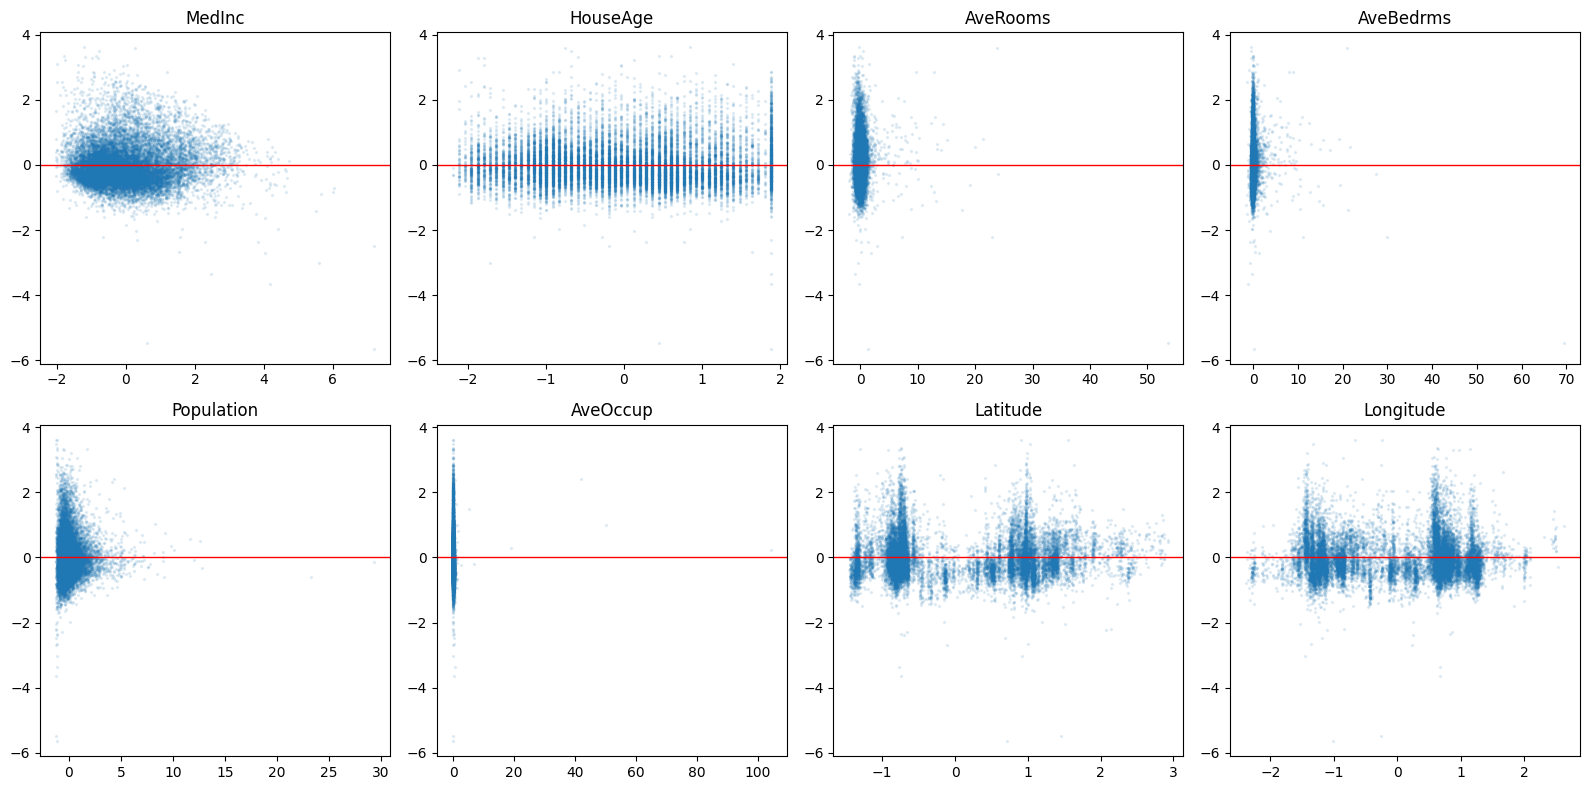

In [21]:
# fit degree 1 model residuals against each feature
residuals_train = y_train - Phi_train @ theta_map_final

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, (name, ax) in enumerate(zip(data.feature_names, axes.flatten())):
    ax.scatter(X_train_s[:, j], residuals_train, alpha=0.1, s=2)
    ax.axhline(0, color='red', linewidth=1)
    ax.set_title(name)
plt.tight_layout()
plt.show()

We would want to try to make our model better by introducing polynomial features. Looking 
at the above plot (residuals against the features), we can see that MedInc could be potential
candidate to poly
nomial feature, and also latitude and longitude together can give us a better
understanding of the data and hopefully represent data well. 

In [22]:
#making new design matrix 
def make_design_matrix_selective(X):
    N = X.shape[0]
    ones = np.ones((N, 1))
    lat = X[:, 6:7]   # Latitude
    lon = X[:, 7:8]   # Longitude
    inc = X[:, 0:1]   # MedInc
    lat_lon = lat * lon
    inc2 = inc ** 2
    return np.hstack([ones, X, inc2, lat_lon])


Phi_sel_train = make_design_matrix_selective(X_train_s)
Phi_sel_test  = make_design_matrix_selective(X_test_s)
print(Phi_sel_train.shape)

(15718, 11)


In [23]:
#cross-validation for finding the best b_j value with best alpha

X_tr2, X_val2,y_tr2, y_val2 = train_test_split(X_train_s, y_train,
                                            test_size = 0.2,random_state = 42)
Phi_2_tr = make_design_matrix_selective(X_tr2)
Phi_2_val = make_design_matrix_selective(X_val2)
#alphas candidates will be the same as earlier
#updating 
b2_inc2   = b2_features[0] * 3        # MedInc squared, scaled up
b2_latlon = np.mean(b2_features) 
val_rmses = []
for alpha in alphas:
    b2_features = alpha* correlations**2
    b2_all = np.concatenate([[1000.0], b2_features, [b2_inc2],[b2_latlon]])
    B = np.diag(b2_all)
    B_inv = np.diag(1/b2_all) +1e-9
    A = Phi_2_tr.T @ Phi_2_tr + sigma2 * B_inv
    b = Phi_2_tr.T @ y_tr2
    #A_theta = b
    theta_map = np.linalg.solve(A,b)#map estimation for parameters
    y_pre = Phi_2_val @ theta_map
    mse = 1/X_val.shape[0]*np.sum((y_val - y_pre)**2)
    rmse = np.sqrt(mse)
    val_rmses.append(rmse)
    


In [24]:
for alpha, rmse in zip(alphas, val_rmses):
    print(f"alpha = {alpha:5.1f} val RMSE = {rmse:.4f}")

best_alpha = alphas[np.argmin(val_rmses)]
print(f"\noptimal alpha: {best_alpha}")

alpha =   0.1 val RMSE = 0.6562
alpha =   0.2 val RMSE = 0.6413
alpha =   0.3 val RMSE = 0.6334
alpha =   0.4 val RMSE = 0.6287
alpha =   0.5 val RMSE = 0.6257
alpha =   1.0 val RMSE = 0.6195
alpha =   2.0 val RMSE = 0.6171
alpha =   3.0 val RMSE = 0.6166
alpha =   3.2 val RMSE = 0.6166
alpha =   5.0 val RMSE = 0.6165
alpha =  10.0 val RMSE = 0.6165
alpha =  50.0 val RMSE = 0.6166

optimal alpha: 5.0


In [25]:
## esting against the original test set using whole training set
optimal_alpha = 5.0
b2_features = optimal_alpha * correlations**2
#b2_matrix with column intercept, degree 1 column, degree2_for_income, lat*lon
b2_all = np.concatenate ([[1000.0],b2_features, [b2_inc2],[b2_latlon]])
B_inv = np.diag(1/b2_all)
A = Phi_sel_train.T @ Phi_sel_train + sigma2 * B_inv
b = Phi_sel_train.T @ y_train
theta_map_final = np.linalg.solve(A,b)
y_pred_final2 = Phi_sel_test @ theta_map_final
rmse_final2 = np.sqrt(1/X_test.shape[0]*np.sum((y_test - y_pred_final2)**2))
print(f"final test RMSE: {rmse_final2:.4f}")


final test RMSE: 0.6432


In [26]:
residuals2 = y_test - y_pred_final2

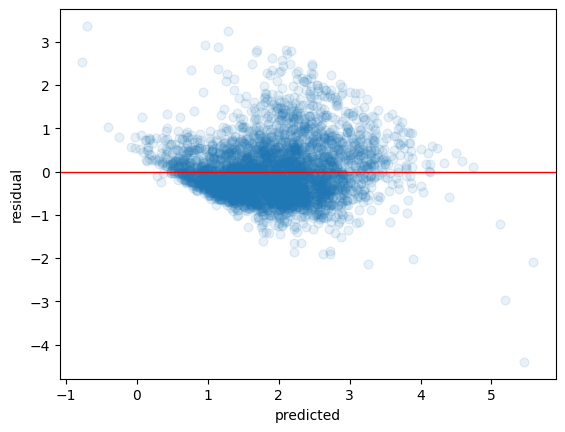

In [27]:
plt.scatter(y_pred_final2, residuals, alpha = 0.1, s = 40)
plt.axhline(0, color = "red", linewidth = 1)
plt.xlabel("predicted")
plt.ylabel("residual")
plt.show()

The selective polynomial model performs similarly to the baseline linear model, with no meaningful improvement in RMSE. This suggests that linear features already capture most of the variance in the data, and the nonlinear terms we added did not contribute significant additional signal.
Two reasons likely explain this. First, the nonlinear relationship in MedInc and the geographic interaction between Latitude and Longitude may be weaker than the residual plots suggested. Second, and more importantly, standardising both Latitude and Longitude to zero-mean before computing their interaction product greatly weakens the signal — multiplying two zero-centered variables produces a feature that is mostly near zero, contributing little to the model.
A better geographic feature would be something like distance from the coast or distance from a major city center, computed before standardisation. More broadly, improving RMSE from here requires either better feature engineering or a more flexible model class — not just tuning the prior.

**Bayesian Inference**
Computing the Posterior Distribution of $\theta$ defined as in Section 6.

In [35]:
S_N_inv = 1/sigma2 * Phi_sel_train.T @ Phi_sel_train + B_inv
S_N = np.linalg.inv(S_N_inv)
M_N = 1/sigma2 * S_N @ Phi_sel_train.T @ y_train

print("m_N:      ", M_N[:4])
print("theta_map:", theta_map[:4])
print("difference:", np.abs(M_N - theta_map_final).max())
print("sigma2:", sigma2)
print("B_inv diagonal:", B_inv.diagonal()[:5])

m_N:       [ 1.92715934  0.67928748  0.10360215 -0.25077097]
theta_map: [ 1.92614938  0.66707731  0.09942517 -0.23426152]
difference: 2.8350585767888958e-14
sigma2: 1.0
B_inv diagonal: [1.00000000e-03 4.76004113e-01 4.81504957e+01 1.62402378e+01
 6.17555554e+01]


As intended and theoritically shown in 6.3,  the $m_N$ and $\theta_{MAP}$ are equal. We now have posterior covariance, i.e. we can know what the coefficients are, but also we now know the uncertainty of those coefficients

In [37]:
print("posterior variance per coefficient:")
for name, var in zip(['bias'] + data.feature_names + ['MedInc²', 'Lat×Lon'], 
                      np.diag(S_N)):
    print(f"  {name:12s}: {var:.6f}")

posterior variance per coefficient:
  bias        : 0.000213
  MedInc      : 0.000194
  HouseAge    : 0.000080
  AveRooms    : 0.000562
  AveBedrms   : 0.000469
  Population  : 0.000066
  AveOccup    : 0.000062
  Latitude    : 0.000597
  Longitude   : 0.000551
  MedInc²     : 0.000026
  Lat×Lon     : 0.000147


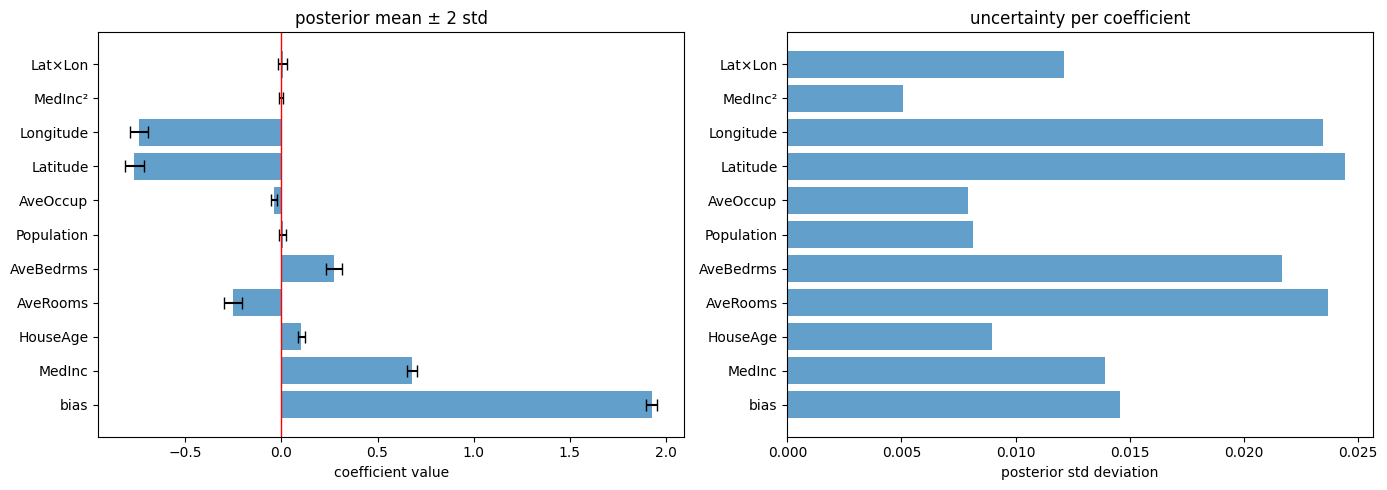

In [42]:
names = ['bias'] + data.feature_names + ['MedInc²', 'Lat×Lon']
variances = np.diag(S_N)
std_devs = np.sqrt(variances)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot: coefficient values with uncertainty bars
axes[0].barh(names, M_N, xerr=2*std_devs, 
             align='center', alpha=0.7, capsize=4)
axes[0].axvline(0, color='red', linewidth=1)
axes[0].set_xlabel('coefficient value')
axes[0].set_title('posterior mean ± 2 std')

# right plot: posterior uncertainty only
axes[1].barh(names, std_devs, align='center', alpha=0.7)
axes[1].set_xlabel('posterior std deviation')
axes[1].set_title('uncertainty per coefficient')

plt.tight_layout()
plt.show()

The left diagram shows the coefficents($\theta$) for each of the feature vectors with uncertainty. The right diagram explains the uncertainly compared with other feature vectors.

**Predicting with Uncertainty**

In [44]:
# predictive mean and variance for each test point
phi_test = Phi_sel_test  # shape (N_test, D)

pred_mean = phi_test @ M_N

# variance for each test point - hint: this is a loop or vectorised
# for each test point phi_*, compute phi_* @ S_N @ phi_* + sigma2
pred_var = np.array([phi_test[i] @ S_N @ phi_test[i] + sigma2 
                     for i in range(len(phi_test))])

pred_std = np.sqrt(pred_var)

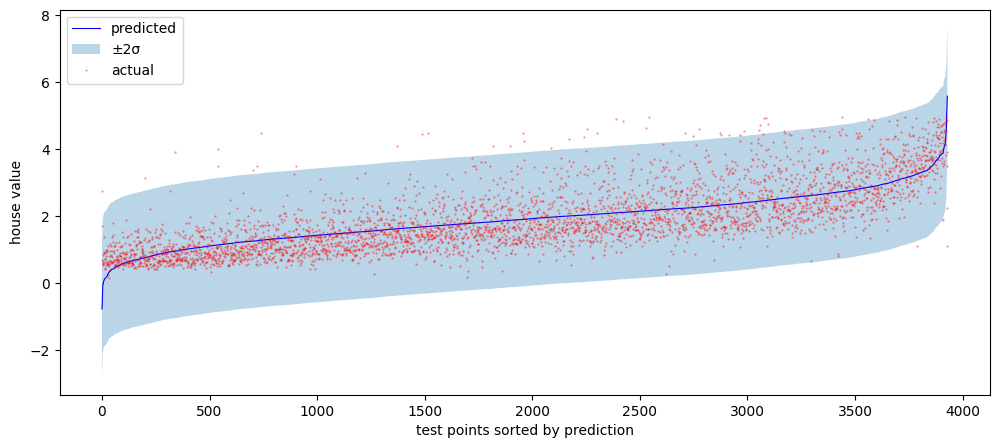

In [45]:
sort_idx = np.argsort(pred_mean)
plt.figure(figsize=(12, 5))
plt.plot(pred_mean[sort_idx], 'b-', linewidth=0.8, label='predicted')
plt.fill_between(range(len(pred_mean)),
                 pred_mean[sort_idx] - 2*pred_std[sort_idx],
                 pred_mean[sort_idx] + 2*pred_std[sort_idx],
                 alpha=0.3, label='±2σ')
plt.plot(y_test[sort_idx], 'r.', markersize=1, alpha=0.5, label='actual')
plt.legend()
plt.xlabel('test points sorted by prediction')
plt.ylabel('house value')
plt.show()

**Result**
 $\mathbf{S}_N$  gave us something MAP never could — a full distribution over  $\boldsymbol{\theta}$
, not just a point estimate. The diagonal of $\mathbf{S}_N$ told us we are most uncertain about Latitude and Longitude, because their individual linear terms cannot fully capture geographic signal alone. The predictive bands showed the model is well-calibrated — approximately 95% of test points fall within $±2\sigma$, and uncertainty correctly widens at the edges where training data is sparse. To improve further, better feature engineering is the priority: replacing raw Latitude and Longitude with distance from the coast or a major city, computed before standardisation, would give the model a geographically meaningful feature rather than two coordinates that lose their interaction signal after centering.

On the other hand, taking away the research perspective, this might be critical as the model is not too surprised if the actual value of house is far away from the predicted value with $±2\sigma$.
